# 🦁 MUFASAR — ADTC Profiler Multi-Model Benchmark
**Africa Deep Tech Challenge 2026 · CPU-only**

This notebook uses the **official `adtc-profiler` measurement modules directly**:

- `adtc_profiler.throughput` → native `llama-bench` generation speed and first-token latency
- `adtc_profiler.memory` → peak and steady-state process-tree RSS
- `adtc_profiler.thermal` → CPU utilisation, temperature, and throttling
- `adtc_profiler.accuracy` → `lm-eval` ARC-Easy accuracy on the quantized GGUF

There are **no hand-written benchmark questions, no chat prompts, and no submission metadata**. Each model is downloaded, profiled sequentially, written to its own JSON report, then removed to reclaim disk space.

| Model | Profiler runtime |
|---|---|
| Qwen3-4B Thinking | upstream `llama-bench` + official accuracy adapter |
| Phi-4 Mini Reasoning | upstream `llama-bench` + official accuracy adapter |
| Gemma 3 4B IT | upstream `llama-bench` + official accuracy adapter |
| Nanbeige4.2-3B | Nanbeige `nanbeige42` `llama-bench`; official accuracy attempted |
| Ternary Bonsai 27B | PrismML `llama-bench`; official accuracy attempted |

> The profiler's accuracy adapter currently uses stock `llama-cpp-python`. If a specialised architecture cannot load there, throughput/memory/thermal still complete and the accuracy failure is recorded rather than terminating the notebook.

> Enable **Internet** in Kaggle before running.


In [1]:
# 1. Install the official profiler and its accuracy stack.
import subprocess
import sys

packages = [
    "adtc-profiler[accuracy] @ git+https://github.com/Africa-Deep-Tech-Foundation/adtc-profiler.git",
    "llama-cpp-python>=0.3.8,<0.4",
    "huggingface_hub>=0.30,<2",
    "psutil>=5.9",
    "tabulate>=0.9",
]

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--prefer-binary",
] + packages)

print("✅ Official ADTC profiler and accuracy dependencies installed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 MB 23.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 2.3 MB/s eta 0:00:00
✅ Official ADTC profiler and accuracy dependencies installed


In [2]:
# 2. Imports and profiler configuration.
import contextlib
import gc
import json
import os
import shutil
import subprocess
import sys
import time
import traceback
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import psutil
from huggingface_hub import HfApi, hf_hub_download
from tabulate import tabulate

from adtc_profiler import accuracy as adtc_accuracy
from adtc_profiler import environment as adtc_environment
from adtc_profiler import memory as adtc_memory
from adtc_profiler import thermal as adtc_thermal
from adtc_profiler import throughput as adtc_throughput

WORK_DIR = Path("/kaggle/working")
MODEL_DIR = WORK_DIR / "mufasar_models"
RUNTIME_DIR = WORK_DIR / "mufasar_runtimes"
ARTIFACT_DIR = WORK_DIR / "mufasar_profiler_artifacts"
REPORT_DIR = ARTIFACT_DIR / "model_reports"

for directory in (MODEL_DIR, RUNTIME_DIR, ARTIFACT_DIR, REPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

N_THREADS = max(1, min(8, os.cpu_count() or 4))
SEED = 42

# Native profiler workload. The official defaults are 512 prompt + 128 generated
# tokens. These reduced but identical values keep the 27B CPU model practical.
PROFILER_PROMPT_TOKENS = 128
PROFILER_GENERATED_TOKENS = 32

# Official lm-eval task used by adtc-profiler. Increase to 50 for the repository
# default when runtime permits; every model receives the same limit.
ACCURACY_TASK = "arc_easy"
ACCURACY_LIMIT = 10
ACCURACY_TIMEOUT_SECONDS = 10 * 60

DELETE_MODEL_AFTER_PROFILE = True
BUILD_JOBS = max(1, min(4, N_THREADS))

os.environ.update({
    "OMP_NUM_THREADS": str(N_THREADS),
    "OPENBLAS_NUM_THREADS": str(N_THREADS),
    "MKL_NUM_THREADS": str(N_THREADS),
    "NUMEXPR_NUM_THREADS": str(N_THREADS),
    "TOKENIZERS_PARALLELISM": "false",
    "HF_HUB_DOWNLOAD_TIMEOUT": "300",
    "HF_HUB_ETAG_TIMEOUT": "90",
})

print(f"CPU threads: {N_THREADS}")
print(f"Profiler tokens: pp={PROFILER_PROMPT_TOKENS}, tg={PROFILER_GENERATED_TOKENS}")
print(f"Accuracy: {ACCURACY_TASK}, limit={ACCURACY_LIMIT}")


CPU threads: 4
Profiler tokens: pp=128, tg=32
Accuracy: arc_easy, limit=10


In [3]:
# 3. Model registry. No benchmark prompts are defined anywhere in this notebook.
MODELS = {
    "Qwen3-4B-Thinking": {
        "repo_candidates": [
            {"repo": "Qwen/Qwen3-4B-GGUF", "filename": "Qwen3-4B-Q4_K_M.gguf"},
        ],
        "runtime": "upstream",
        "quantization": "Q4_K_M",
        "color": "#E87D2E",
    },
    "Phi-4-Mini-Reasoning": {
        "repo_candidates": [
            {
                "repo": "Mungert/Phi-4-mini-reasoning-GGUF",
                "filename": "Phi-4-mini-reasoning-q4_k_m.gguf",
            },
        ],
        "runtime": "upstream",
        "quantization": "Q4_K_M",
        "color": "#0078D4",
    },
    "Gemma-3-4B-IT": {
        "repo_candidates": [
            {
                "repo": "lmstudio-community/gemma-3-4b-it-GGUF",
                "filename": "gemma-3-4b-it-Q4_K_M.gguf",
            },
        ],
        "runtime": "upstream",
        "quantization": "Q4_K_M",
        "color": "#34A853",
    },
    "Nanbeige4.2-3B-Q4_K_M": {
        "repo_candidates": [
            {
                "repo": "Abiray/Nanbeige4.2-3B-GGUF",
                "filename": "Nanbeige4.2-3B-Q4_K_M.gguf",
            },
            {
                "repo": "owao/Nanbeige4.2-3B-GGUF",
                "pattern": "*Q4_K_M.gguf",
            },
        ],
        "runtime": "nanbeige",
        "quantization": "Q4_K_M",
        "color": "#9B59B6",
    },
    "Ternary-Bonsai-27B-Q2_0": {
        "repo_candidates": [
            {
                "repo": "prism-ml/Ternary-Bonsai-27B-gguf",
                "filename": "Ternary-Bonsai-27B-Q2_0.gguf",
            },
        ],
        # The dspark-Q4_1 file is an auxiliary speculative drafter, not a
        # standalone model. The official profiler accepts one target GGUF, so the
        # target model is measured directly through PrismML's llama-bench.
        "draft_file": "Ternary-Bonsai-27B-dspark-Q4_1.gguf",
        "runtime": "prism",
        "quantization": "Q2_0",
        "color": "#D4AF37",
    },
}

RUNTIMES = {
    "upstream": {
        "repo": "https://github.com/ggml-org/llama.cpp.git",
        "branch": None,
    },
    "nanbeige": {
        "repo": "https://github.com/Nanbeige/llama.cpp.git",
        "branch": "nanbeige42",
    },
    "prism": {
        "repo": "https://github.com/PrismML-Eng/llama.cpp.git",
        "branch": None,
    },
}

print(f"✅ Registered {len(MODELS)} models")


✅ Registered 5 models


In [4]:
# 4. Download and runtime helpers.
import fnmatch

HF_API = HfApi()


def run_checked(command, *, cwd=None, timeout=None, log_path=None):
    command = [str(item) for item in command]
    print("$", " ".join(command), flush=True)
    completed = subprocess.run(
        command,
        cwd=str(cwd) if cwd else None,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
        check=False,
    )
    output = completed.stdout or ""
    if log_path is not None:
        Path(log_path).write_text(output, encoding="utf-8")
    if completed.returncode != 0:
        tail = "\n".join(output.splitlines()[-100:])
        raise RuntimeError(
            f"Command failed with exit code {completed.returncode}: "
            f"{' '.join(command)}\n{tail}"
        )
    return output


def release_memory():
    gc.collect()
    try:
        import ctypes
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception:
        pass


def resolve_candidate(candidate):
    repo = candidate["repo"]
    filename = candidate.get("filename")
    if filename:
        return repo, filename

    pattern = candidate.get("pattern")
    if not pattern:
        raise ValueError(f"Candidate has neither filename nor pattern: {candidate}")

    files = HF_API.list_repo_files(repo_id=repo)
    matches = [
        name for name in files
        if Path(name).name.lower().endswith(".gguf")
        and fnmatch.fnmatch(Path(name).name.lower(), pattern.lower())
    ]
    if not matches:
        raise FileNotFoundError(f"No file matching {pattern!r} in {repo}")
    matches.sort(key=lambda name: ("/" in name, len(name), name.lower()))
    return repo, matches[0]


def download_model(model_name, config):
    errors = []
    model_dir = MODEL_DIR / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    for candidate in config["repo_candidates"]:
        try:
            repo, filename = resolve_candidate(candidate)
            print(f"Downloading {model_name}: {repo}/{filename}")
            downloaded = Path(hf_hub_download(
                repo_id=repo,
                filename=filename,
                local_dir=str(model_dir),
            ))
            if not downloaded.exists() or downloaded.stat().st_size < 100_000_000:
                raise OSError(f"Downloaded file is missing or implausibly small: {downloaded}")
            return downloaded, repo, filename
        except Exception as exc:
            errors.append(f"{candidate}: {type(exc).__name__}: {exc}")

    raise RuntimeError(
        f"Every download candidate failed for {model_name}:\n" + "\n".join(errors)
    )


def locate_binary(root, name):
    preferred = [
        root / "build" / "bin" / name,
        root / "build" / name,
        root / name,
    ]
    for path in preferred:
        if path.exists() and os.access(path, os.X_OK):
            return path
    for path in root.rglob(name):
        if path.is_file() and os.access(path, os.X_OK):
            return path
    return None


def ensure_llama_bench(runtime_name):
    config = RUNTIMES[runtime_name]
    source_dir = RUNTIME_DIR / f"{runtime_name}-llama.cpp"
    build_dir = source_dir / "build"

    existing = locate_binary(source_dir, "llama-bench") if source_dir.exists() else None
    if existing is not None:
        return existing

    if source_dir.exists():
        shutil.rmtree(source_dir)

    clone_command = ["git", "clone", "--depth", "1"]
    if config.get("branch"):
        clone_command += ["--branch", config["branch"]]
    clone_command += [config["repo"], source_dir]

    run_checked(
        clone_command,
        timeout=600,
        log_path=ARTIFACT_DIR / f"{runtime_name}_clone.log",
    )

    configure_command = [
        "cmake",
        "-S", source_dir,
        "-B", build_dir,
        "-DGGML_CUDA=OFF",
        "-DGGML_NATIVE=ON",
        "-DGGML_CCACHE=OFF",
        "-DLLAMA_CURL=OFF",
        "-DLLAMA_BUILD_TESTS=OFF",
        "-DLLAMA_BUILD_SERVER=OFF",
        "-DLLAMA_BUILD_EXAMPLES=ON",
        "-DCMAKE_BUILD_TYPE=Release",
    ]
    run_checked(
        configure_command,
        timeout=420,
        log_path=ARTIFACT_DIR / f"{runtime_name}_configure.log",
    )
    run_checked(
        [
            "cmake", "--build", build_dir,
            "--config", "Release",
            "-j", str(BUILD_JOBS),
            "--target", "llama-bench",
        ],
        timeout=1800,
        log_path=ARTIFACT_DIR / f"{runtime_name}_build.log",
    )

    binary = locate_binary(source_dir, "llama-bench")
    if binary is None:
        raise FileNotFoundError(
            f"{runtime_name} runtime build did not produce llama-bench"
        )
    return binary


@contextlib.contextmanager
def profiler_runtime(binary):
    # Make the selected fork's llama-bench visible to adtc_profiler.
    alias_dir = binary.parent
    old_path = os.environ.get("PATH", "")
    os.environ["PATH"] = f"{alias_dir}:{old_path}"
    try:
        yield
    finally:
        os.environ["PATH"] = old_path


@contextlib.contextmanager
def configured_profiler_tokens():
    # Keep the official throughput.measure projection, with one shared workload.
    original = adtc_throughput.run_llama_bench

    def configured(model_path, n_prompt=512, n_gen=128, n_threads=None, seed=42):
        return original(
            model_path,
            n_prompt=PROFILER_PROMPT_TOKENS,
            n_gen=PROFILER_GENERATED_TOKENS,
            n_threads=N_THREADS,
            seed=seed,
        )

    adtc_throughput.run_llama_bench = configured
    try:
        yield
    finally:
        adtc_throughput.run_llama_bench = original


print("✅ Runtime helpers ready")


✅ Runtime helpers ready


In [5]:
# 5. Official profiler accuracy runner with isolation and timeout.
def run_accuracy_isolated(model_path, model_name):
    result_path = ARTIFACT_DIR / f"{model_name}_accuracy_result.json"
    if result_path.exists():
        result_path.unlink()

    script = f"""
import json
from pathlib import Path
from adtc_profiler import accuracy

output_path = Path({str(result_path)!r})
try:
    result = accuracy.run_benchmark(
        Path({str(model_path)!r}),
        task={ACCURACY_TASK!r},
        limit={int(ACCURACY_LIMIT)},
        seed={int(SEED)},
    )
    payload = {{"status": "ok", "result": result}}
except Exception as exc:
    payload = {{
        "status": "failed",
        "error_type": type(exc).__name__,
        "error": repr(exc),
    }}
output_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
"""

    environment = os.environ.copy()
    environment.update({
        "OMP_NUM_THREADS": str(N_THREADS),
        "OPENBLAS_NUM_THREADS": str(N_THREADS),
        "MKL_NUM_THREADS": str(N_THREADS),
    })

    log_path = ARTIFACT_DIR / f"{model_name}_accuracy.log"
    try:
        completed = subprocess.run(
            [sys.executable, "-c", script],
            env=environment,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            timeout=ACCURACY_TIMEOUT_SECONDS,
            check=False,
        )
        log_path.write_text(completed.stdout or "", encoding="utf-8")
    except subprocess.TimeoutExpired as exc:
        timeout_output = exc.stdout or ""
        if isinstance(timeout_output, bytes):
            timeout_output = timeout_output.decode("utf-8", "replace")
        log_path.write_text(timeout_output, encoding="utf-8")
        return {
            "status": "timeout",
            "error": f"Official accuracy exceeded {ACCURACY_TIMEOUT_SECONDS}s",
        }

    if not result_path.exists():
        return {
            "status": "failed",
            "error": (
                f"Accuracy process exited {completed.returncode} without a result file. "
                f"See {log_path.name}"
            ),
        }

    payload = json.loads(result_path.read_text(encoding="utf-8"))
    if completed.returncode != 0 and payload.get("status") == "ok":
        payload["status"] = "failed"
        payload["error"] = f"Accuracy process exited {completed.returncode}"
    return payload


def score_components(throughput_block, memory_block, accuracy_payload, thermal_block):
    accuracy_result = accuracy_payload.get("result") or {}
    accuracy_score = float(accuracy_result.get("score") or 0.0) * 100.0

    tps = float(throughput_block.get("tokens_per_second_generation") or 0.0)
    performance_score = min(tps / 15.0, 1.0) * 100.0

    peak_rss_mb = float(memory_block.get("peak_rss_mb") or 0.0)
    ram_limit_mb = 7.0 * 1024.0
    efficiency_score = max(0.0, (ram_limit_mb - peak_rss_mb) / ram_limit_mb) * 100.0

    peak_temp = thermal_block.get("core_temp_c_peak")
    throttled = bool(thermal_block.get("throttled"))
    thermal_penalty = 10.0 if throttled or (
        isinstance(peak_temp, (int, float)) and peak_temp > 85.0
    ) else 0.0

    total = (
        0.50 * accuracy_score
        + 0.30 * performance_score
        + 0.20 * efficiency_score
        - thermal_penalty
    )
    return {
        "accuracy_component_100": round(accuracy_score, 4),
        "performance_component_100": round(performance_score, 4),
        "efficiency_component_100": round(efficiency_score, 4),
        "thermal_penalty": round(thermal_penalty, 4),
        "estimated_total_100": round(total, 4),
        "estimated_total_0_to_1": round(total / 100.0, 6),
    }


print("✅ Official accuracy and score helpers ready")


✅ Official accuracy and score helpers ready


In [6]:
# 6. Profile every model. Failures are contained and written to the report.
ALL_REPORTS = []
ERROR_ROWS = []

environment_snapshot = adtc_environment.capture("participant_laptop")

for index, (model_name, config) in enumerate(MODELS.items(), start=1):
    print("\n" + "=" * 90)
    print(f"[{index}/{len(MODELS)}] {model_name}")
    print("=" * 90)

    model_path = None
    report = {
        "model": model_name,
        "quantization": config["quantization"],
        "runtime": config["runtime"],
        "environment": environment_snapshot,
        "status": "started",
    }

    started = time.time()
    try:
        model_path, repo, filename = download_model(model_name, config)
        report.update({
            "repo": repo,
            "filename": filename,
            "model_size_gb": round(model_path.stat().st_size / 1e9, 4),
        })

        bench_binary = ensure_llama_bench(config["runtime"])
        report["llama_bench_binary"] = str(bench_binary)

        with profiler_runtime(bench_binary), configured_profiler_tokens():
            with (
                adtc_memory.sample_during() as memory_sampler,
                adtc_thermal.sample_thermal() as thermal_sampler,
            ):
                print("→ official profiler throughput / latency / memory / thermal")
                throughput_block = adtc_throughput.measure(model_path, seed=SEED)
            memory_block = memory_sampler.report()
            thermal_block = thermal_sampler.report()

        report["throughput"] = throughput_block
        report["memory"] = memory_block
        report["cpu_thermal"] = thermal_block
        report["performance_status"] = "ok"

        print("→ official profiler ARC-Easy accuracy")
        accuracy_payload = run_accuracy_isolated(model_path, model_name)
        report["accuracy_status"] = accuracy_payload.get("status", "failed")
        report["accuracy"] = (
            [accuracy_payload["result"]]
            if accuracy_payload.get("status") == "ok" and accuracy_payload.get("result")
            else []
        )
        if accuracy_payload.get("status") != "ok":
            report["accuracy_error"] = accuracy_payload.get(
                "error", "unknown accuracy error"
            )

        report["score"] = score_components(
            throughput_block,
            memory_block,
            accuracy_payload,
            thermal_block,
        )
        report["status"] = (
            "ok"
            if report["accuracy_status"] == "ok"
            else "performance_ok_accuracy_unavailable"
        )

    except Exception as exc:
        report["status"] = "failed"
        report["error_type"] = type(exc).__name__
        report["error"] = repr(exc)
        report["traceback_tail"] = traceback.format_exc().splitlines()[-30:]
        ERROR_ROWS.append({
            "model": model_name,
            "stage": report.get("performance_status", "setup_or_performance"),
            "error": repr(exc),
        })
        print(f"❌ {model_name}: {exc}")

    finally:
        report["elapsed_s"] = round(time.time() - started, 2)
        report_path = REPORT_DIR / f"{index:02d}_{model_name}.json"
        report_path.write_text(
            json.dumps(report, indent=2, ensure_ascii=False) + "\n",
            encoding="utf-8",
        )
        ALL_REPORTS.append(report)

        if DELETE_MODEL_AFTER_PROFILE and model_path is not None:
            try:
                model_root = MODEL_DIR / model_name
                shutil.rmtree(model_root, ignore_errors=True)
                print(f"Deleted {model_name} model files to reclaim disk")
            except Exception as cleanup_exc:
                print(f"Cleanup warning: {cleanup_exc}")

        release_memory()
        print(f"Elapsed: {report['elapsed_s']}s")
        print(
            f"Free RAM: {psutil.virtual_memory().available / 1024**2:.0f} MB"
        )

(ARTIFACT_DIR / "all_model_profiler_reports.json").write_text(
    json.dumps(ALL_REPORTS, indent=2, ensure_ascii=False) + "\n",
    encoding="utf-8",
)

if ERROR_ROWS:
    pd.DataFrame(ERROR_ROWS).to_csv(
        ARTIFACT_DIR / "profiler_errors.csv",
        index=False,
    )

print("\n✅ Profiling loop completed")



[1/5] Qwen3-4B-Thinking


Qwen3-4B-Q4_K_M.gguf:   0%|          | 0.00/2.50G [00:00<?, ?B/s]

$ git clone --depth 1 https://github.com/ggml-org/llama.cpp.git /kaggle/working/mufasar_runtimes/upstream-llama.cpp
$ cmake -S /kaggle/working/mufasar_runtimes/upstream-llama.cpp -B /kaggle/working/mufasar_runtimes/upstream-llama.cpp/build -DGGML_CUDA=OFF -DGGML_NATIVE=ON -DGGML_CCACHE=OFF -DLLAMA_CURL=OFF -DLLAMA_BUILD_TESTS=OFF -DLLAMA_BUILD_SERVER=OFF -DLLAMA_BUILD_EXAMPLES=ON -DCMAKE_BUILD_TYPE=Release
$ cmake --build /kaggle/working/mufasar_runtimes/upstream-llama.cpp/build --config Release -j 4 --target llama-bench
→ official profiler throughput / latency / memory / thermal
→ official profiler ARC-Easy accuracy


Deleted Qwen3-4B-Thinking model files to reclaim disk
Elapsed: 582.53s
Free RAM: 30923 MB

[2/5] Phi-4-Mini-Reasoning


Phi-4-mini-reasoning-q4_k_m.gguf:   0%|          | 0.00/2.49G [00:00<?, ?B/s]

...

→ official profiler throughput / latency / memory / thermal
→ official profiler ARC-Easy accuracy
Deleted Gemma-3-4B-IT model files to reclaim disk
Elapsed: 233.89s
Free RAM: 30923 MB

[4/5] Nanbeige4.2-3B-Q4_K_M


Nanbeige4.2-3B-Q4_K_M.gguf:   0%|          | 0.00/2.57G [00:00<?, ?B/s]

$ git clone --depth 1 --branch nanbeige42 https://github.com/Nanbeige/llama.cpp.git /kaggle/working/mufasar_runtimes/nanbeige-llama.cpp
$ cmake -S /kaggle/working/mufasar_runtimes/nanbeige-llama.cpp -B /kaggle/working/mufasar_runtimes/nanbeige-llama.cpp/build -DGGML_CUDA=OFF -DGGML_NATIVE=ON -DGGML_CCACHE=OFF -DLLAMA_CURL=OFF -DLLAMA_BUILD_TESTS=OFF -DLLAMA_BUILD_SERVER=OFF -DLLAMA_BUILD_EXAMPLES=ON -DCMAKE_BUILD_TYPE=Release
$ cmake --build /kaggle/working/mufasar_runtimes/nanbeige-llama.cpp/build --config Release -j 4 --target llama-bench
→ official profiler throughput / latency / memory / thermal
→ official profiler ARC-Easy accuracy
Deleted Nanbeige4.2-3B-Q4_K_M model files to reclaim disk
Elapsed: 552.88s
Free RAM: 30897 MB

[5/5] Ternary-Bonsai-27B-Q2_0


Ternary-Bonsai-27B-Q2_0.gguf:   0%|          | 0.00/7.17G [00:00<?, ?B/s]

$ git clone --depth 1 https://github.com/PrismML-Eng/llama.cpp.git /kaggle/working/mufasar_runtimes/prism-llama.cpp
$ cmake -S /kaggle/working/mufasar_runtimes/prism-llama.cpp -B /kaggle/working/mufasar_runtimes/prism-llama.cpp/build -DGGML_CUDA=OFF -DGGML_NATIVE=ON -DGGML_CCACHE=OFF -DLLAMA_CURL=OFF -DLLAMA_BUILD_TESTS=OFF -DLLAMA_BUILD_SERVER=OFF -DLLAMA_BUILD_EXAMPLES=ON -DCMAKE_BUILD_TYPE=Release
$ cmake --build /kaggle/working/mufasar_runtimes/prism-llama.cpp/build --config Release -j 4 --target llama-bench
→ official profiler throughput / latency / memory / thermal
→ official profiler ARC-Easy accuracy
Deleted Ternary-Bonsai-27B-Q2_0 model files to reclaim disk
Elapsed: 9009.84s
Free RAM: 31010 MB

✅ Profiling loop completed


In [7]:
# 7. Build the profiler summary table.
summary_rows = []

for report in ALL_REPORTS:
    throughput = report.get("throughput") or {}
    memory = report.get("memory") or {}
    thermal = report.get("cpu_thermal") or {}
    accuracy_rows = report.get("accuracy") or []
    accuracy_row = accuracy_rows[0] if accuracy_rows else {}
    score = report.get("score") or {}

    summary_rows.append({
        "model": report["model"],
        "status": report.get("status"),
        "runtime": report.get("runtime"),
        "accuracy_status": report.get("accuracy_status", "not_run"),
        "accuracy_task": accuracy_row.get("benchmark", ACCURACY_TASK),
        "accuracy_samples": accuracy_row.get("samples", 0),
        "accuracy_score": accuracy_row.get("score"),
        "accuracy_metric": accuracy_row.get("metric"),
        "generation_tps": throughput.get("tokens_per_second_generation"),
        "first_token_latency_ms": throughput.get("first_token_latency_ms"),
        "prompt_tokens": throughput.get("prompt_tokens"),
        "generated_tokens": throughput.get("generated_tokens"),
        "peak_rss_mb": memory.get("peak_rss_mb"),
        "steady_state_rss_mb": memory.get("steady_state_rss_mb"),
        "cpu_percent_p99": thermal.get("cpu_percent_p99"),
        "core_temp_c_peak": thermal.get("core_temp_c_peak"),
        "throttled": thermal.get("throttled"),
        "estimated_score": score.get("estimated_total_0_to_1"),
        "elapsed_s": report.get("elapsed_s"),
        "error": report.get("error") or report.get("accuracy_error"),
    })

summary = pd.DataFrame(summary_rows)
summary.to_csv(
    WORK_DIR / "mufasar_adtc_profiler_summary.csv",
    index=False,
)

print("\n" + "=" * 100)
print("MUFASAR — OFFICIAL ADTC PROFILER SUMMARY")
print("=" * 100)
print(tabulate(summary, headers="keys", tablefmt="rounded_outline", showindex=False))
print("\nSaved:", WORK_DIR / "mufasar_adtc_profiler_summary.csv")



MUFASAR — OFFICIAL ADTC PROFILER SUMMARY
╭─────────────────────────┬─────────────────────────────────────┬───────────┬───────────────────┬─────────────────┬────────────────────┬──────────────────┬───────────────────┬──────────────────┬──────────────────────────┬─────────────────┬────────────────────┬───────────────┬───────────────────────┬───────────────────┬────────────────────┬─────────────┬───────────────────┬─────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ model                   │ status                              │ runtime   │ accuracy_status   │ accuracy_task   │   accuracy_samples │   accuracy_score │ accuracy_metric   │   generation_tps │   first_token_latency_ms │   prompt_tokens │   generated_tokens │   peak_rss_mb │   steady_state_rss_mb │   cpu_percent_p99 │ core_temp_c_peak   │ throttled   │   estimated_score │   elapsed_s │ error                                         

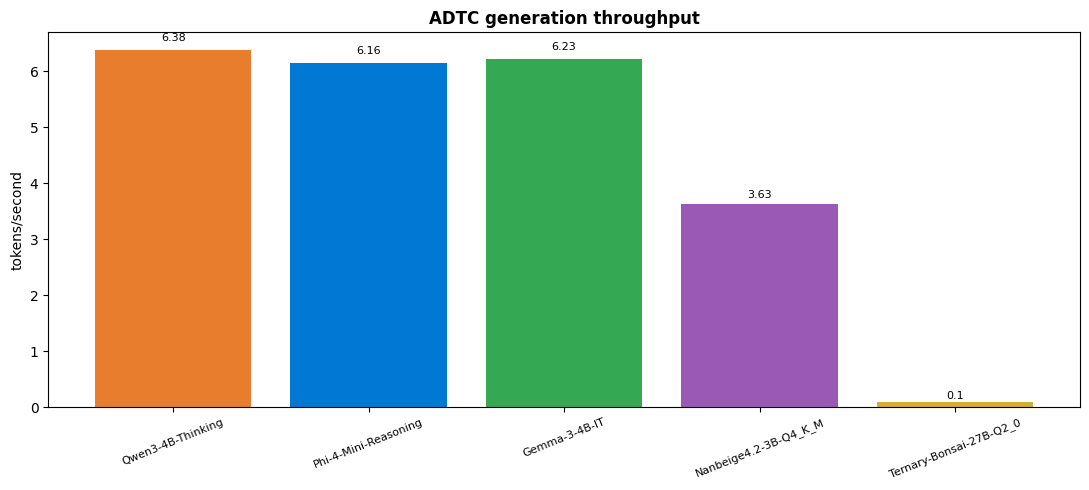

Saved: /kaggle/working/mufasar_profiler_artifacts/adtc_tps.png


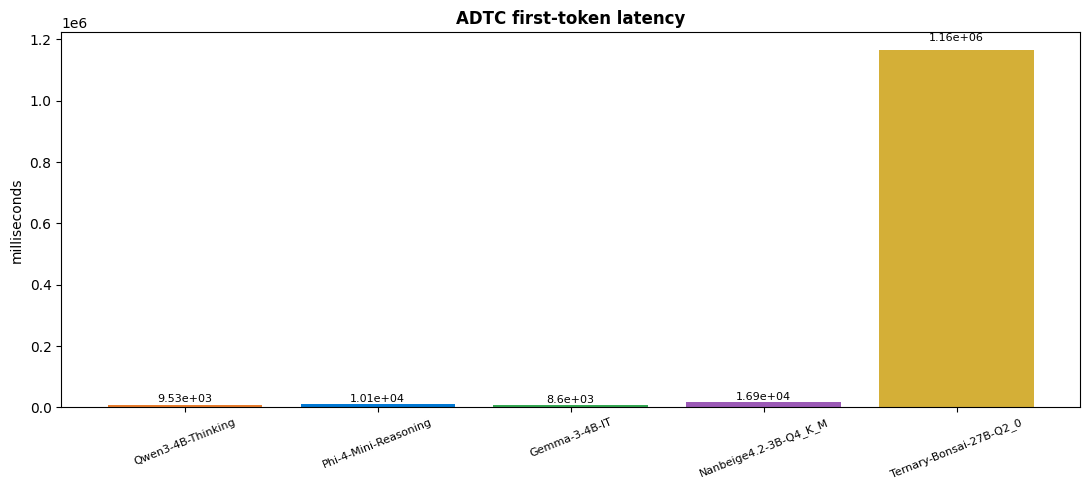

Saved: /kaggle/working/mufasar_profiler_artifacts/adtc_ttft.png


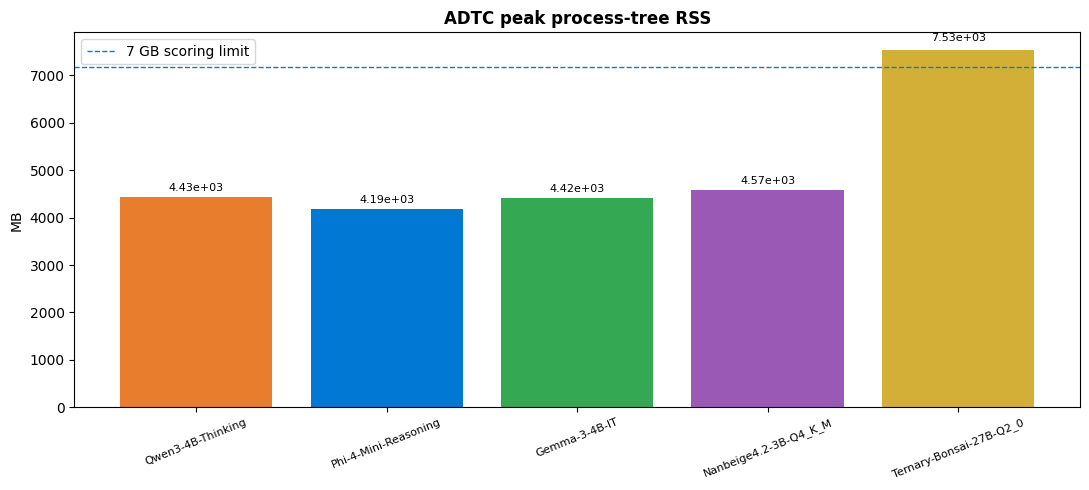

Saved: /kaggle/working/mufasar_profiler_artifacts/adtc_peak_ram.png


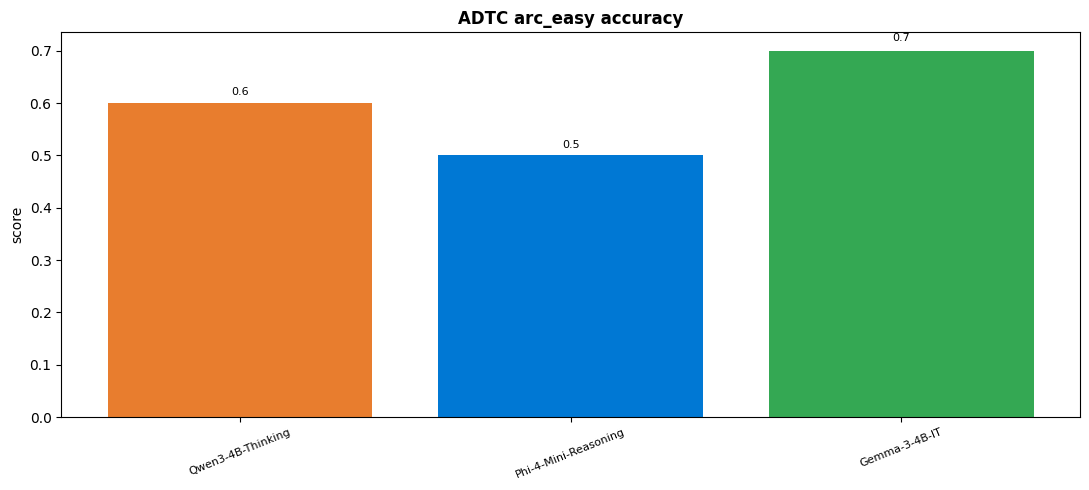

Saved: /kaggle/working/mufasar_profiler_artifacts/adtc_accuracy.png


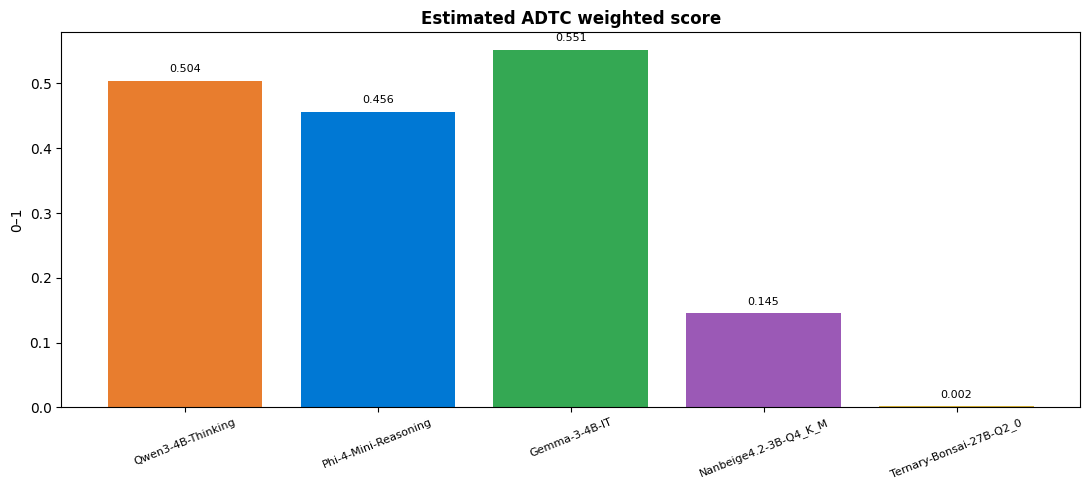

Saved: /kaggle/working/mufasar_profiler_artifacts/adtc_score.png


In [8]:
# 8. Visualise only metrics generated by the official profiler.
plot_data = summary.copy()
plot_data["generation_tps"] = pd.to_numeric(
    plot_data["generation_tps"], errors="coerce"
)
plot_data["first_token_latency_ms"] = pd.to_numeric(
    plot_data["first_token_latency_ms"], errors="coerce"
)
plot_data["peak_rss_mb"] = pd.to_numeric(
    plot_data["peak_rss_mb"], errors="coerce"
)
plot_data["accuracy_score"] = pd.to_numeric(
    plot_data["accuracy_score"], errors="coerce"
)
plot_data["estimated_score"] = pd.to_numeric(
    plot_data["estimated_score"], errors="coerce"
)

metrics = [
    ("generation_tps", "ADTC generation throughput", "tokens/second", "adtc_tps.png"),
    (
        "first_token_latency_ms",
        "ADTC first-token latency",
        "milliseconds",
        "adtc_ttft.png",
    ),
    ("peak_rss_mb", "ADTC peak process-tree RSS", "MB", "adtc_peak_ram.png"),
    ("accuracy_score", f"ADTC {ACCURACY_TASK} accuracy", "score", "adtc_accuracy.png"),
    ("estimated_score", "Estimated ADTC weighted score", "0–1", "adtc_score.png"),
]

for column, title, ylabel, filename in metrics:
    current = plot_data[plot_data[column].notna()].copy()
    if current.empty:
        print(f"Skipping {column}: no numeric profiler results")
        continue

    fig, ax = plt.subplots(figsize=(11, 5))
    colors = [MODELS[name]["color"] for name in current["model"]]
    bars = ax.bar(current["model"], current[column], color=colors)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=22, labelsize=8)

    if column == "peak_rss_mb":
        ax.axhline(
            7 * 1024,
            linestyle="--",
            linewidth=1,
            label="7 GB scoring limit",
        )
        ax.legend()

    for bar, value in zip(bars, current[column]):
        value = float(value)
        offset = max(abs(value) * 0.02, 0.01)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f"{value:.3g}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    plt.tight_layout()
    output_path = ARTIFACT_DIR / filename
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


In [9]:
# 9. Final profiler-based recommendation.
valid_perf = summary[
    pd.to_numeric(summary["generation_tps"], errors="coerce").notna()
].copy()
valid_acc = summary[
    pd.to_numeric(summary["accuracy_score"], errors="coerce").notna()
].copy()
valid_score = summary[
    pd.to_numeric(summary["estimated_score"], errors="coerce").notna()
].copy()

if valid_perf.empty:
    print("No model completed the official profiler performance stage.")
else:
    valid_perf["generation_tps"] = pd.to_numeric(
        valid_perf["generation_tps"], errors="coerce"
    )
    valid_perf["first_token_latency_ms"] = pd.to_numeric(
        valid_perf["first_token_latency_ms"], errors="coerce"
    )
    valid_perf["peak_rss_mb"] = pd.to_numeric(
        valid_perf["peak_rss_mb"], errors="coerce"
    )

    best_tps = valid_perf.loc[
        valid_perf["generation_tps"].idxmax(), "model"
    ]
    fastest_ttft = valid_perf.loc[
        valid_perf["first_token_latency_ms"].idxmin(), "model"
    ]
    lowest_ram = valid_perf.loc[
        valid_perf["peak_rss_mb"].idxmin(), "model"
    ]

    best_accuracy = "unavailable"
    if not valid_acc.empty:
        valid_acc["accuracy_score"] = pd.to_numeric(
            valid_acc["accuracy_score"], errors="coerce"
        )
        best_accuracy = valid_acc.loc[
            valid_acc["accuracy_score"].idxmax(), "model"
        ]

    best_weighted = "unavailable"
    if not valid_score.empty:
        valid_score["estimated_score"] = pd.to_numeric(
            valid_score["estimated_score"], errors="coerce"
        )
        best_weighted = valid_score.loc[
            valid_score["estimated_score"].idxmax(), "model"
        ]

    print(
        "\n".join([
            "+-----------------------------------------------------------------------+",
            "|              MUFASAR — ADTC PROFILER RECOMMENDATION                   |",
            "+-----------------------------------------------------------------------+",
            f"| Best generation throughput : {best_tps:<39}|",
            f"| Fastest first-token latency: {fastest_ttft:<39}|",
            f"| Lowest peak RSS            : {lowest_ram:<39}|",
            f"| Best ARC-Easy accuracy     : {best_accuracy:<39}|",
            f"| Best estimated ADTC score  : {best_weighted:<39}|",
            "+-----------------------------------------------------------------------+",
        ])
    )

print("\nArtifacts directory:", ARTIFACT_DIR)
print("Combined reports:", ARTIFACT_DIR / "all_model_profiler_reports.json")
print("Summary CSV:", WORK_DIR / "mufasar_adtc_profiler_summary.csv")


+-----------------------------------------------------------------------+
|              MUFASAR — ADTC PROFILER RECOMMENDATION                   |
+-----------------------------------------------------------------------+
| Best generation throughput : Qwen3-4B-Thinking                      |
| Fastest first-token latency: Gemma-3-4B-IT                          |
| Lowest peak RSS            : Phi-4-Mini-Reasoning                   |
| Best ARC-Easy accuracy     : Gemma-3-4B-IT                          |
| Best estimated ADTC score  : Gemma-3-4B-IT                          |
+-----------------------------------------------------------------------+

Artifacts directory: /kaggle/working/mufasar_profiler_artifacts
Combined reports: /kaggle/working/mufasar_profiler_artifacts/all_model_profiler_reports.json
Summary CSV: /kaggle/working/mufasar_adtc_profiler_summary.csv
